# 1. Setup and Authentication
In this section, we install required libraries and authenticate with Hopsworks.

In [1]:
!pip install -q hopsworks pandas numpy openmeteo-requests requests-cache retry-requests matplotlib seaborn scikit-learn xgboost shap confluent-kafka

In [2]:
import pandas as pd
import numpy as np
import hopsworks
import openmeteo_requests
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["HOPSWORKS_API_KEY"] = user_secrets.get_secret("HOPSWORKS_API_KEY")

project = hopsworks.login()
fs = project.get_feature_store()

2026-06-05 06:12:49,040 INFO: Initializing external client
2026-06-05 06:12:49,041 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-06-05 06:12:51,036 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33087


# 2. Fetch Historical Data from OpenMeteo
We fetch historical weather and air quality data for Karachi (24.832862, 67.033866) from 2020 to present.

In [4]:
def fetch_openmeteo_historical(lat, lon, start_date, end_date):
    cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    # 1. Weather Data
    weather_url = 'https://archive-api.open-meteo.com/v1/archive'
    weather_params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': start_date,
        'end_date': end_date,
        'hourly': ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m']
    }
    weather_response = openmeteo.weather_api(weather_url, params=weather_params)[0]
    hourly_weather = weather_response.Hourly()

    weather_data = {
        'date': pd.date_range(
            start=pd.to_datetime(hourly_weather.Time(), unit='s', utc=True),
            end=pd.to_datetime(hourly_weather.TimeEnd(), unit='s', utc=True),
            freq=pd.Timedelta(seconds=hourly_weather.Interval()),
            inclusive='left'
        ),
        'temperature': hourly_weather.Variables(0).ValuesAsNumpy(),
        'humidity': hourly_weather.Variables(1).ValuesAsNumpy(),
        'precipitation': hourly_weather.Variables(2).ValuesAsNumpy(),
        'pressure': hourly_weather.Variables(3).ValuesAsNumpy(),
        'wind_speed': hourly_weather.Variables(4).ValuesAsNumpy(),
        'wind_direction': hourly_weather.Variables(5).ValuesAsNumpy()
    }
    df_weather = pd.DataFrame(data=weather_data)

    # 2. Air Quality Data
    aqi_url = 'https://air-quality-api.open-meteo.com/v1/air-quality'
    aqi_params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': start_date,
        'end_date': end_date,
        'hourly': ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'us_aqi']
    }
    aqi_response = openmeteo.weather_api(aqi_url, params=aqi_params)[0]
    hourly_aqi = aqi_response.Hourly()

    aqi_data = {
        'date': pd.date_range(
            start=pd.to_datetime(hourly_aqi.Time(), unit='s', utc=True),
            end=pd.to_datetime(hourly_aqi.TimeEnd(), unit='s', utc=True),
            freq=pd.Timedelta(seconds=hourly_aqi.Interval()),
            inclusive='left'
        ),
        'pm10': hourly_aqi.Variables(0).ValuesAsNumpy(),
        'pm2_5': hourly_aqi.Variables(1).ValuesAsNumpy(),
        'carbon_monoxide': hourly_aqi.Variables(2).ValuesAsNumpy(),
        'nitrogen_dioxide': hourly_aqi.Variables(3).ValuesAsNumpy(),
        'sulphur_dioxide': hourly_aqi.Variables(4).ValuesAsNumpy(),
        'ozone': hourly_aqi.Variables(5).ValuesAsNumpy(),
        'aqi': hourly_aqi.Variables(6).ValuesAsNumpy()
    }
    df_aqi = pd.DataFrame(data=aqi_data)

    # Merge
    df = pd.merge(df_weather, df_aqi, on='date', how='inner')
    df.dropna(inplace=True)
    return df

karachi_lat, karachi_lon = 24.832862, 67.033866
end_date = datetime.now().strftime('%Y-%m-%d')
df = fetch_openmeteo_historical(karachi_lat, karachi_lon, '2023-01-01', end_date)
df.head()

,date,temperature,humidity,precipitation,pressure,wind_speed,wind_direction,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,2023-01-01 00:00:00+00:00,15.55,83.689461,0.0,1018.738342,10.137692,16.504446,61.200001,36.599998,567.0,23.049999,26.950001,76.0,136.125000
1,2023-01-01 01:00:00+00:00,14.60,88.669945,0.0,1019.136841,9.605998,347.005371,57.000000,33.500000,668.0,30.250000,30.400000,66.0,136.093750
2,2023-01-01 02:00:00+00:00,14.80,88.976830,0.0,1019.637024,10.703569,340.346100,63.599998,38.799999,811.0,40.450001,35.250000,53.0,135.677094
3,2023-01-01 03:00:00+00:00,15.85,81.562561,0.0,1020.238159,11.503113,339.863586,66.599998,40.700001,967.0,50.400002,41.049999,44.0,135.604172
4,2023-01-01 04:00:00+00:00,18.10,63.647331,0.0,1020.940735,9.565437,340.201019,73.300003,45.500000,1028.0,52.099998,44.250000,51.0,135.385406


# 3. Feature Engineering & Target Creation
We create derived features (time-based features, moving averages) and our targets (AQI in 24h, 48h, 72h).

In [5]:
def create_features_and_targets(df):
    df = df.copy()
    # Time-based features
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    
    # Derived features (e.g., AQI change rate over 24h)
    df['aqi_24h_rolling_mean'] = df['aqi'].rolling(window=24).mean()
    df['aqi_change_rate'] = df['aqi'].pct_change(periods=24)
    
    # Create targets (predicting AQI at +24h, +48h, +72h)
    # We shift negative because we want the target column on row T to be the AQI at T+H
    df['target_aqi_24h'] = df['aqi'].shift(-24)
    df['target_aqi_48h'] = df['aqi'].shift(-48)
    df['target_aqi_72h'] = df['aqi'].shift(-72)
    
    df.dropna(inplace=True)
    # Format date as integer timestamp for Hopsworks primary key
    df['timestamp'] = df['date'].astype('int64') // 10**6
    return df

df_processed = create_features_and_targets(df)
print(df_processed.shape)
df_processed.tail()

(29952, 23)


,date,temperature,humidity,precipitation,pressure,wind_speed,wind_direction,pm10,pm2_5,carbon_monoxide,...,aqi,hour,day_of_week,month,aqi_24h_rolling_mean,aqi_change_rate,target_aqi_24h,target_aqi_48h,target_aqi_72h,timestamp
29971,2026-06-02 19:00:00+00:00,28.750000,80.211899,0.0,1004.758728,8.836514,266.496521,65.900002,28.299999,133.0,...,89.609940,19,1,6,83.909206,0.141244,86.994682,94.148949,85.886528,1780426800000
29972,2026-06-02 20:00:00+00:00,28.549999,79.708130,0.0,1004.958679,6.854196,293.198608,60.099998,26.799999,117.0,...,89.893623,20,1,6,84.357271,0.135880,87.437943,93.829796,85.124115,1780430400000
29973,2026-06-02 21:00:00+00:00,28.299999,80.392891,0.0,1004.758362,4.542994,303.690094,57.700001,25.500000,110.0,...,90.035461,21,1,6,84.796100,0.132471,88.209221,93.226959,84.441490,1780434000000
29974,2026-06-02 22:00:00+00:00,28.100000,82.066940,0.0,1004.458252,2.305125,321.340179,55.299999,24.000000,111.0,...,90.097519,22,1,6,85.220154,0.127343,89.051414,92.517738,83.891846,1780437600000
29975,2026-06-02 23:00:00+00:00,27.950001,82.540810,0.0,1003.958435,4.072935,135.000107,51.900002,22.900000,120.0,...,90.044327,23,1,6,85.625370,0.121082,89.840424,91.914902,83.395386,1780441200000


# 4. Exploratory Data Analysis (EDA)
Visualize correlations to see which features impact AQI the most.

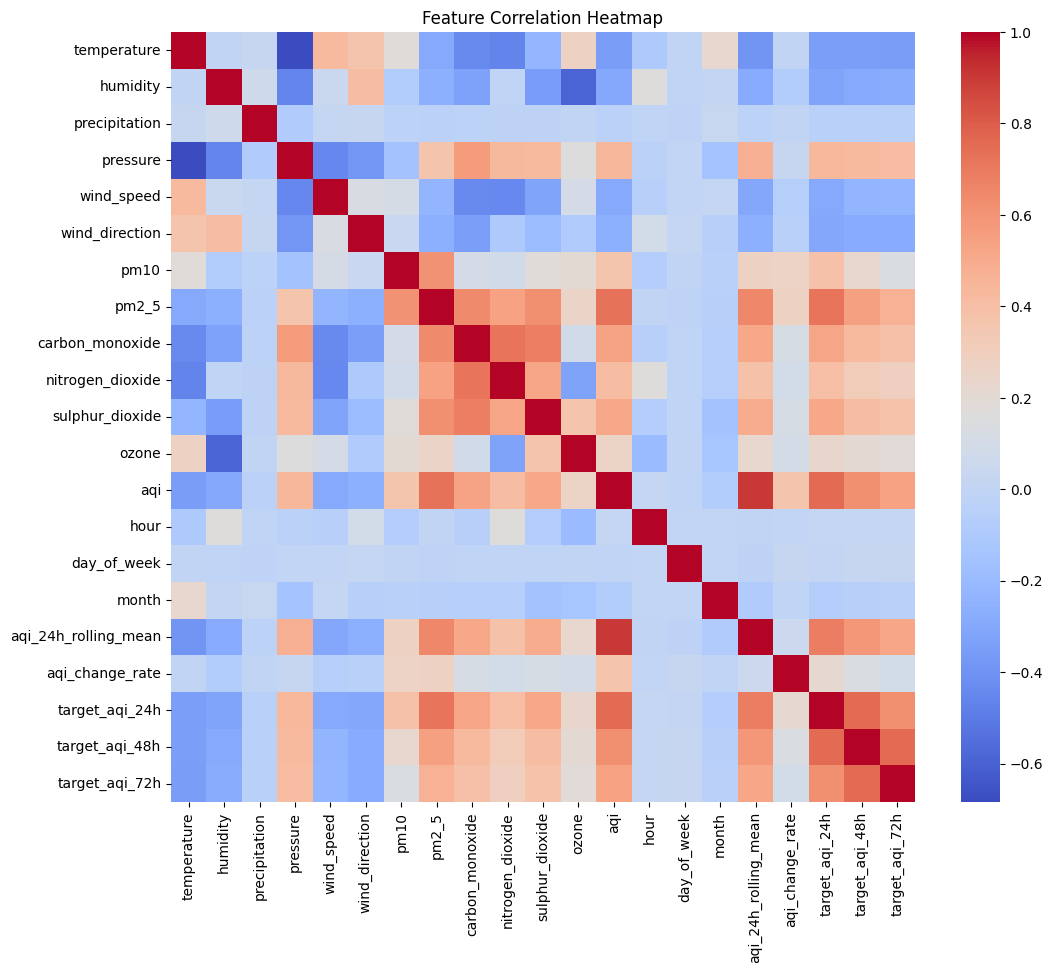

In [6]:
plt.figure(figsize=(12, 10))
corr = df_processed.drop(['date', 'timestamp'], axis=1).corr()
sns.heatmap(corr, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 5. Save to Hopsworks Feature Store
We push this clean dataset to Hopsworks so our training pipeline can pull it.

In [7]:
aqi_fg = fs.get_or_create_feature_group(
    name='aqi_features',
    version=1,
    primary_key=['timestamp'],
    event_time='timestamp',
    description='Karachi weather and AQI features'
)

aqi_fg.insert(df_processed)

Uploading Dataframe: 100.00% |██████████| Rows 29952/29952 | Elapsed Time: 00:13 | Remaining Time: 00:00


Launching job: aqi_features_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://eu-west.cloud.hopsworks.ai:443/p/33087/jobs/named/aqi_features_1_offline_fg_materialization/executions


(Job('aqi_features_1_offline_fg_materialization', 'SPARK'), None)